# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Annisa Dewiyanti
- **Email:** annisadewiyanti6@gmail.com
- **ID Dicoding:** andwynt

## Menentukan Pertanyaan Bisnis

1. When are the highest and lowest frequency periods (hours) for bike rentals?

2. Which season shows the highest volume of bike rentals, and how do seasonal factors influence demand?

3. What is the ratio between registered and casual renters?

## Import Semua Packages/Library yang Digunakan

In [ ]:
# calling all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
# Loading the day table
day_df = pd.read_csv("day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
# Loading the hour table
hour_df = pd.read_csv("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

In [ ]:
# Checking the statistical parameters of the numerical columns in day_df
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [ ]:
# Checking the data types of each column in hour_df and day_df
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [ ]:
# Checking for missing values in the hour_df dataset
hour_df.info()
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex:

In [ ]:
# Checking for missing values in the day_df dataset
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [ ]:
# Checking for missing values in the day_df dataset
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [ ]:
# Checking for duplicate data
print("Number of duplicates: ", hour_df.duplicated().sum())
print("Number of duplicates: ", day_df.duplicated().sum())

Number of duplicates:  0
Number of duplicates:  0


#### **1. The Target Variable**
The primary variable of interest is **`cnt` (total count of bikes rented)**. This count is composed of two distinct user groups:
* **`casual`** users (non-registered, one-time riders).
* **`registered`** users (subscribers or frequent riders).

**Insight:** Any future analysis should look at how features (like weather or time) affect `casual` and `registered` rentals separately, as these groups likely have different rental patterns. For example, registered users may be commuters, making them less sensitive to minor weather changes than casual tourists.

---

#### **2. Data Timeframe**
The data covers a **two-year period** (731 entries in the daily table).

**Insight:** The `yr` column (year) allows for a year-over-year comparison. This is crucial for checking if bike demand is growing, stagnating, or declining, or if user behavior has changed between the two years the data was collected.

---

#### **3. Key Predictors**

The columns suggest three major areas that will influence bike rental demand:

| Predictor Type | Columns | Potential Impact |
| :--- | :--- | :--- |
| **Time Cycle** | `season`, `mnth`, `hr`, `weekday` | Demand will be **highly cyclical** (e.g., peak demand in summer/fall, during the day, and on weekdays for commuters). |
| **Events** | `holiday`, `workingday` | Demand patterns will **switch significantly** on holidays and non-working days (e.g., higher casual use, lower registered use). |
| **Weather** | `temp`, `atemp`, `hum`, `windspeed`, `weathersit` | **Temperature** will likely have a **strong positive correlation** with demand, while adverse conditions (`weathersit` > 1, high `hum`, high `windspeed`) will have a **strong negative correlation**. |

**Insight:** Modeling bike demand will essentially be an exercise in quantifying how much each of these time and weather variables contributes to the total **`cnt`**.

---

#### **4. Data Types for Modeling**

While the data is clean, a key preparatory step is implied by the current data types:

* **Categorical vs. Numeric:** Columns like `season`, `mnth`, `weekday`, and `weathersit` are currently stored as `int64`. In reality, they are **categorical variables** where the numbers (1, 2, 3, 4) do not represent a measurable quantity, but distinct groups (e.g., Spring, Summer, Fall, Winter).
* **Insight:** Before building a predictive model, these columns must be correctly treated as categories (e.g., using One-Hot Encoding) to prevent the model from incorrectly assuming that a value of '4' is twice as important as a value of '2'.

### Cleaning Data

In [ ]:
# Drop 'instant' (irrelevant) and 'workingday' (redundant with 'weekday').
hour_df.drop(['workingday'], axis = 1, inplace= True)
day_df.drop(['workingday'], axis = 1, inplace= True)

Mengubah Tipe Data

* `int` to category

In [ ]:
# Convert the data types of 'season', 'mnth', 'holiday', 'weekday', and 'weathersit' from int to category.
columns = ['season', 'mnth', 'holiday', 'weekday', 'weathersit']

for column in columns:
    day_df[column] =  day_df[column].astype("category")
    hour_df[column] =  hour_df[column].astype("category")

* `object` to datetime



In [ ]:
# Convert 'dteday' data type from 'object' to 'datetime'.
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

Rename

In [ ]:
# Cleaning column names in `hour_df`.
hour_df.rename(columns={'yr':'year','hr':'hours','mnth':'month','weekday':'one_of_week', 'weathersit':'weather_situation','windspeed':'wind_speed','cnt':'count_cr','hum':'humidity'},inplace=True)

In [ ]:
# Cleaning column names in `day_df`.
day_df.rename(columns={'yr':'year','mnth':'month','weekday':'one_of_week', 'weathersit':'weather_situation', 'windspeed':'wind_speed','cnt':'count_cr','hum':'humidity'},inplace=True)

In [ ]:
# Standardizing categorical columns by replacing numerical codes with descriptive labels for readability.
# also converting normalized 'humidity' values to actual percentages.

# Season conversion: 1:Spring, 2:Summer, 3:Fall, 4:Winter
day_df.season.replace((1,2,3,4), ('Spring','Summer','Fall','Winter'), inplace=True)
hour_df.season.replace((1,2,3,4), ('Spring','Summer','Fall','Winter'), inplace=True)

# Month conversion: 1:Jan to 12:Dec
day_df.month.replace((1,2,3,4,5,6,7,8,9,10,11,12),('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'), inplace=True)
hour_df.month.replace((1,2,3,4,5,6,7,8,9,10,11,12),('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'), inplace=True)

# Weather situation conversion: 1:Clear, 2:Misty, 3:Light_RainSnow 4:Heavy_RainSnow
day_df.weather_situation.replace((1,2,3,4), ('Clear','Misty','Light_rainsnow','Heavy_rainsnow'), inplace=True)
hour_df.weather_situation.replace((1,2,3,4), ('Clear','Misty','Light_rainsnow','Heavy_rainsnow'), inplace=True)

# Weekday conversion: 0:Sun to 6:Sat
day_df.one_of_week.replace((0,1,2,3,4,5,6), ('Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'), inplace=True)
hour_df.one_of_week.replace((0,1,2,3,4,5,6), ('Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'), inplace=True)

# Year conversion: 0:2011, 1:2012
day_df.year.replace((0,1), ('2011','2012'), inplace=True)
hour_df.year.replace((0,1), ('2011','2012'), inplace=True)

# Convert normalized 'humidity' to percentage value
day_df['humidity'] = day_df['humidity']*100
hour_df['humidity'] = hour_df['humidity']*100

/tmp/ipython-input-2426435834.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  day_df.season.replace((1,2,3,4), ('Spring','Summer','Fall','Winter'), inplace=True)
/tmp/ipython-input-2426435834.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  day_df.season.replace((1,2,3,4), ('Spring','Summer','Fall','Winter'),

Create 'category_days' column to classify records as 'weekend' or 'weekdays'

In [ ]:
# Define function to categorize days
def get_category_days(day_of_week):
    # 'Saturday' and 'Sunday' are weekends; others are weekdays
    if day_of_week in ["Saturday", "Sunday"]:
        return "weekend"
    else:
        return "weekdays"

# Apply the function to both dataframes
hour_df["category_days"] = hour_df["one_of_week"].apply(get_category_days)
day_df["category_days"] = day_df["one_of_week"].apply(get_category_days)

In [ ]:
def classify_humidity(humidity):
    if humidity < 45:
        return "Terlalu kering"
    elif humidity >= 45 and humidity < 65:
        return "Ideal"
    else:
        return "Terlalu Lembab"

hour_df["humidity_category"] = hour_df["humidity"].apply(classify_humidity)
day_df["humidity_category"] = day_df["humidity"].apply(classify_humidity)

**Insight:**

**We have successfully completed the following steps:**

* **Dropped** the `instant` and `workingday` columns.
* **Converted** the `dteday` column's data type to **datetime**.
* **Changed** the data type of `season`, `mnth`, `holiday`, `weekday`, and `weathersit` from integer to **category**.
* **Renamed** columns for **better readability**.
* **Converted** categorical column content into **easily understandable labels**.
* **Created** a new column, `category_days`, classifying records as **weekend** or **weekdays**.

## Exploratory Data Analysis (EDA)

### Explore Data day_df

In [ ]:
# descriptive statistics of the day_df data.
day_df.describe(include="all")

,instant,dteday,season,year,month,holiday,one_of_week,weather_situation,temp,atemp,humidity,wind_speed,casual,registered,count_cr,category_days,humidity_category
count,731.000000,731,731,731,731,731.0,731,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731,731
unique,NaN,NaN,4,2,12,2.0,7,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3
top,NaN,NaN,Fall,2012,Jan,0.0,Sunday,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,weekdays,Ideal
freq,NaN,NaN,188,366,62,710.0,105,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,521,334
mean,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.495385,0.474354,62.789406,0.190486,848.176471,3656.172367,4504.348837,NaN,NaN
min,1.000000,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000,NaN,NaN
25%,183.500000,2011-07-02 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.337083,0.337842,52.000000,0.134950,315.500000,2497.000000,3152.000000,NaN,NaN
50%,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.498333,0.486733,62.666700,0.180975,713.000000,3662.000000,4548.000000,NaN,NaN
75%,548.500000,2012-07-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.655417,0.608602,73.020850,0.233214,1096.000000,4776.500000,5956.000000,NaN,NaN
max,731.000000,2012-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.861667,0.840896,97.250000,0.507463,3410.000000,6946.000000,8714.000000,NaN,NaN


**insight:**

#### **1. Overall Data and Time**
* The dataset covers **731** days (likely two full years).
* The data is 100% complete for all displayed features.
* Most days are non-holidays (710 out of 731).
* Data is evenly distributed across the 7 days of the week.

***

#### **2. Rental Demand**

* **Total Daily Average:** About 4,504 bikes are rented daily.
* Registered users are the main customers, making up over 80\% of all rentals.
* **Demand Swings:** The number of rentals changes significantly from day to day
* **Busiest Day:** The highest demand recorded was 8,714 rentals.

***

#### **3. Weather Conditions**
* **Most Common Weather** The weather is mostlyclear (463 days).
* **Humidity:** Humidity levels are generally high (average is about 63%).
* **Wind:** The wind speed is typically low.

In [ ]:
# Examine the total rentals per season.
day_df.groupby(by="season").count_cr.sum().sort_values(ascending=False).reset_index().head(10)

/tmp/ipython-input-2358580065.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby(by="season").count_cr.sum().sort_values(ascending=False).reset_index().head(10)


,season,count_cr
0,Fall,1061129
1,Summer,918589
2,Winter,841613
3,Spring,471348


**Insight:** Fall and summer are known to be the two seasons with the highest numbers.

In [ ]:
# Annual rental volume breakdown by registered and casual users.
day_df.groupby(by="year").agg({
    "registered": ["sum"],
    "casual": ["sum"]
})

,registered,casual
,sum,sum
year,,
2011,995851,247252
2012,1676811,372765


**Insight:**
- xxx
- xxx

## Visualization & Explanatory Analysis

1. When are the highest and lowest frequency periods (hours) for bike rentals?

2. Which season shows the highest volume of bike rentals, and how do seasonal factors influence demand?

3. What is the ratio between registered and casual renters?

### Pertanyaan 1: When are the highest and lowest frequency periods (hours) for bike rentals?

In [ ]:
# group by hours and count_cr
sum_order_items_df = hour_df.groupby("hours").count_cr.sum().sort_values(ascending=False).reset_index()

/tmp/ipython-input-812224479.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="hours", y="count_cr", data=sum_order_items_df.head(5), palette=["#D3D3D3", "#D3D3D3", "#90CAF9", "#D3D3D3", "#D3D3D3"], ax=ax[0])
/tmp/ipython-input-812224479.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="hours", y="count_cr", data=sum_order_items_df.sort_values(by="hours", ascending=True).head(5), palette=["#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3","#90CAF9"], ax=ax[1])


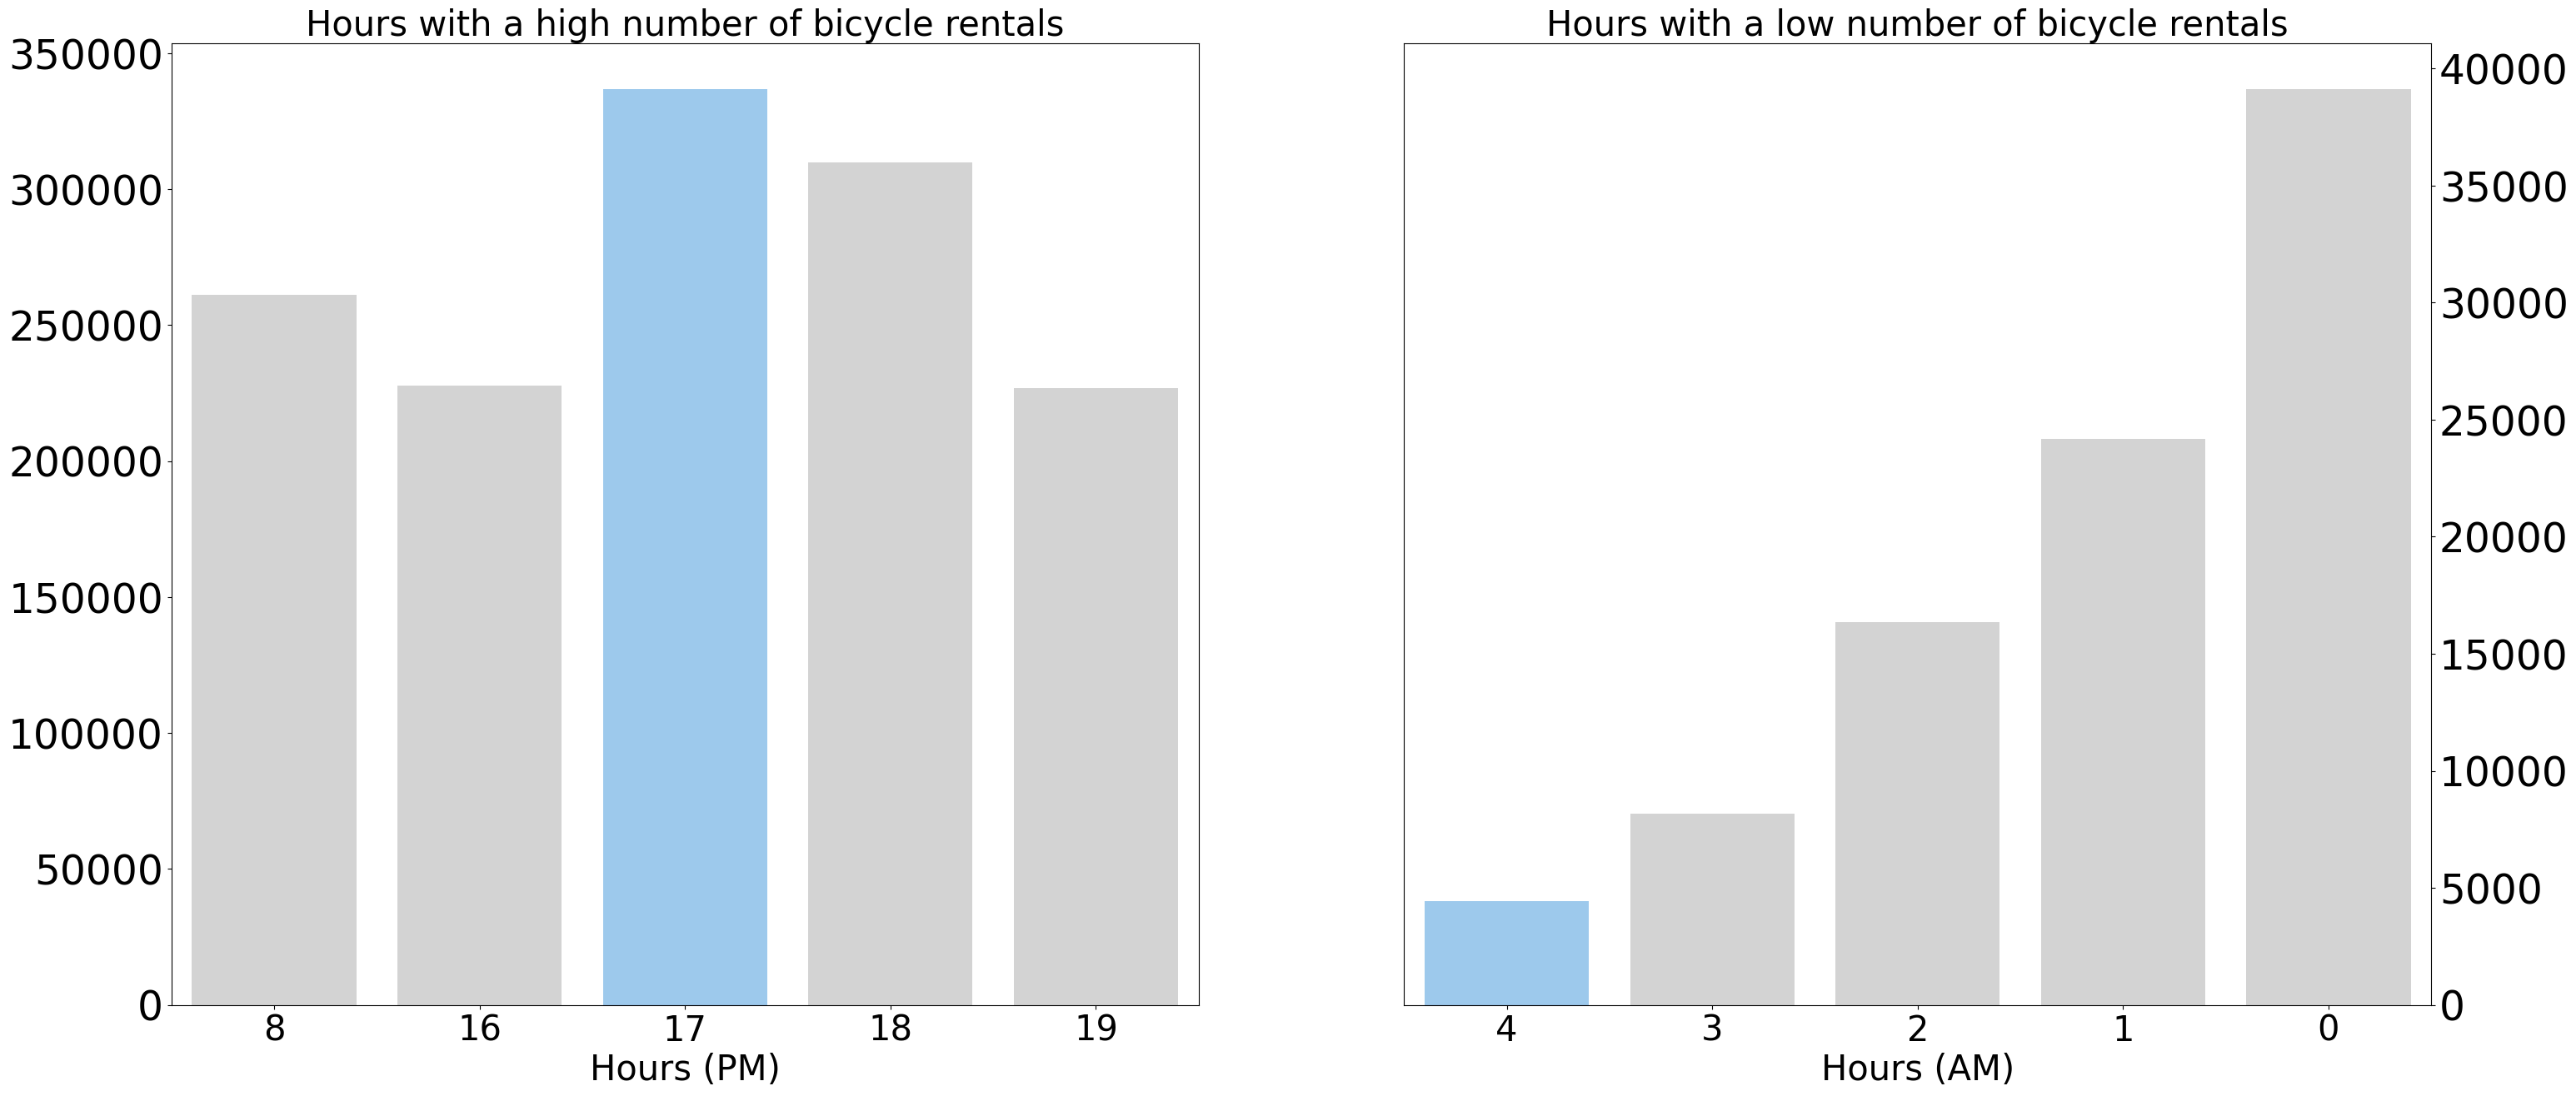

In [ ]:
# bar chart
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(35, 15))

# barplot for the maximum bicycle rentals
sns.barplot(x="hours", y="count_cr", data=sum_order_items_df.head(5), palette=["#D3D3D3", "#D3D3D3", "#90CAF9", "#D3D3D3", "#D3D3D3"], ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("Hours (PM)", fontsize=30)
ax[0].set_title("Hours with a high number of bicycle rentals", loc="center", fontsize=30)
ax[0].tick_params(axis='y', labelsize=35)
ax[0].tick_params(axis='x', labelsize=30)

# bar plot for the minimum bicycle rentals
sns.barplot(x="hours", y="count_cr", data=sum_order_items_df.sort_values(by="hours", ascending=True).head(5), palette=["#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3","#90CAF9"], ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("Hours (AM)",  fontsize=30)
ax[1].set_title("Hours with a low number of bicycle rentals", loc="center", fontsize=30)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].tick_params(axis='y', labelsize=35)
ax[1].tick_params(axis='x', labelsize=30)

# showing plot
plt.show()

**Insight:**
1. **Peak Demand Hours (PM)**
The highest number of bicycle rentals occurs during the evening commuting hours, specifically **5 PM** (17:00).
The three most popular hours **(5 PM, 6 PM, and 4 PM)** are responsible for over 900,000 total rentals, indicating a strong focus on the afternoon rush hour.

2. **Trough Demand Hours (AM)**
The lowest number of bicycle rentals occurs in the early morning hours.
**4 AM** has the absolute lowest demand, which is typical for a non-24-hour service or a system heavily reliant on daily commuting.

### Pertanyaan 2: Which season shows the highest volume of bike rentals, and how do seasonal factors influence demand?

/tmp/ipython-input-3440069283.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


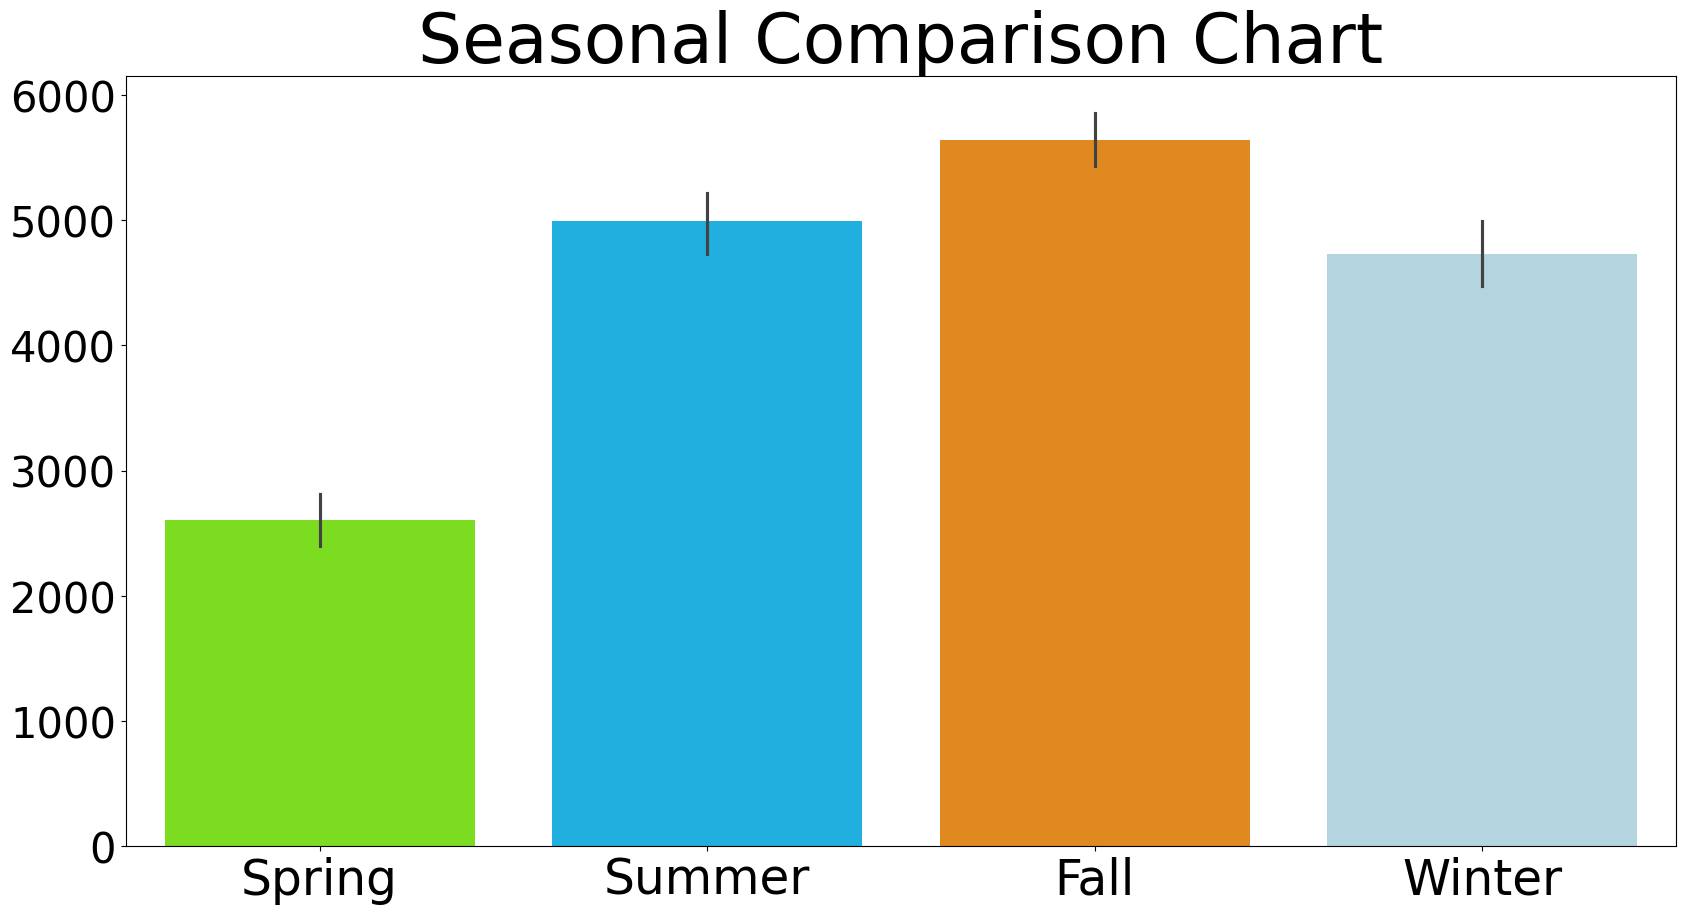

In [ ]:
# create a subplot with a size of (20, 10).
fig, ax = plt.subplots(figsize=(20, 10))

# define colors
colors = ["#7CFC00", "#00BFFF", "#FF8C00", "#ADD8E6"]

# create a barplot for y='count_cr' and x='season', using the data day_df
sns.barplot(
        y="count_cr",
        x="season",
        data=day_df.sort_values(by="season", ascending=False),
        palette=colors,
        ax=ax
    )
ax.set_title("Seasonal Comparison Chart", loc="center", fontsize=50)
ax.set_ylabel(None)
ax.set_xlabel(None)
ax.tick_params(axis='x', labelsize=35)
ax.tick_params(axis='y', labelsize=30)


# Showing plot
plt.show()

**Insight:**
* Fall is the season with the highest number of rentals, totaling 1,061,129.

### Pertanyaan 3: What is the ratio between registered and casual renters?

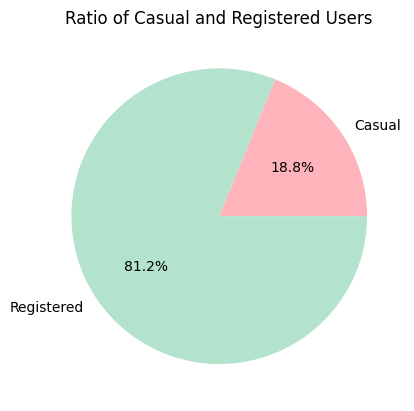

In [ ]:
total_casual = sum(day_df['casual'])
total_registered = sum(day_df['registered'])

# Prepare the data for the pie chart
data = [total_casual, total_registered]
labels = ['Casual', 'Registered']

plt.pie(data, labels=labels, autopct='%1.1f%%', colors=["#FFB3BA", "#B3E2CD"])
plt.title('Ratio of Casual and Registered Users')

# Display the pie chart
plt.show()

**insight**

1. Dominance of Registered Users
Registered users are the vast majority of the customer base, accounting for 81.2% of all bike rentals.

2. Minority of Casual Users
Casual users (non-registered or one-time riders) make up only 18.8% of the total rentals.

## Analisis Lanjutan (Opsional)

RFM Analysis is used below to understand customer behavior based on three key factors:

1. Recency (how recently a customer interacted)
2. Frequency (how often customers interact)
3. Monetary (how much money they spend)

In [ ]:
current_date = max(hour_df['dteday'])
rfm_df = hour_df.groupby('registered').agg({
    'dteday': lambda x: (current_date - x.max()).days,  # Recency
    'instant': 'count',  # Frequency
    'count_cr': 'sum'  # Monetary
}).reset_index()

rfm_df.columns = ['registered', 'Recency', 'Frequency', 'Monetary']

print(rfm_df.head())

   registered  Recency  Frequency  Monetary
0           0       38         24        35
1           1        0        201       294
2           2        1        245       648
3           3        0        294      1154
4           4        3        307      1602


**insight:**

Nilai Pelanggan Bertambah Seiring Waktu: Pelanggan 4, yang bukan pelanggan terbaru (sudah agak lama/Recency 3), adalah yang paling sering menyewa dan paling banyak mengeluarkan uang ($1602).

Pelanggan Baru Masih Rendah: Pelanggan yang paling baru (Recency 0, seperti Pelanggan 1 dan 3) masih memiliki frekuensi dan total pengeluaran yang jauh lebih kecil.

Ini berarti perusahaan harus fokus untuk mempertahankan pelanggan baru dan mendorong mereka agar terus menggunakan layanan sehingga mencapai level loyalitas dan pengeluaran tinggi seperti Pelanggan 4.

## Conclusion

Layanan penyewaan sepeda ini adalah bisnis yang sangat stabil dan sukses, dengan fondasi yang kuat dari pelanggan terdaftar yang loyal, terbukti dari kontribusi mereka yang mencapai lebih dari 81% dari total penyewaan.

Pola ini semakin diperkuat oleh analisis RFM yang menunjukkan bahwa nilai pelanggan meningkat signifikan seiring waktu, di mana pelanggan yang sudah lama menjadi pengguna adalah yang paling sering menyewa dan paling banyak mengeluarkan uang.

Operasi layanan ini sangat terikat pada aktivitas harian komuter, terlihat dari puncak permintaan yang terkonsentrasi di musim gugur dan terutama pada jam sibuk sore hari, yaitu pukul 5 sore.

Untuk strategi pertumbuhan ke depan, perusahaan harus mempertahankan dan memelihara loyalitas pelanggan baru agar mereka berkembang menjadi pelanggan bernilai tinggi, sekaligus secara aktif menargetkan segmen penyewa kasual (yang saat ini minoritas, 18.8%) melalui promosi untuk membuka sumber pendapatan baru.